In [2]:
%pip install numpy==2.5.0 matplotlib==3.11.0 qiskit==2.4.2 qiskit-aer==0.17.2 scikit-learn==1.9.0

!pip install pylatexenc

!pip install qiskit_machine_learning
!pip install qiskit.algorithms

%pip install haiqu.sdk

  Using cached qiskit_machine_learning-0.9.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 2.0 MB/s eta 0:00:00
  Using cached qiskit_algorithms-0.4.0-py3-none-any.whl.metadata (4.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 673.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 4.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.3/167.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 43.3 MB/s eta

In [41]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector, Pauli

from sklearn.datasets import load_iris, make_moons, make_classification, load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score,
    precision_score, fbeta_score, f1_score, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibratedClassifierCV

from sklearn.utils import Bunch

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

from haiqu.sdk import haiqu
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
from google.colab import drive
drive.mount('/content/drive')
dftrain = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/train.csv")
dftest = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/test.csv")
dftrain.head()

Mounted at /content/drive


,SUBJECTID,HER2pos,MRI_pct_change,MRI_shrinkage_early,is_TN,PgRpos,ERpos,MRI_LD_Baseline,age,PCR,HER2pos_scaled,MRI_pct_change_scaled,MRI_shrinkage_early_scaled,is_TN_scaled,PgRpos_scaled,ERpos_scaled,MRI_LD_Baseline_scaled,age_scaled
0,1188,0.0,50.000000,2.0,1.0,0.0,0.0,20.0,38.26,0.0,0.0,2.169195,1.247044,3.141593,0.000000,0.000000,0.019040,0.798242
1,1013,0.0,92.957746,1.0,0.0,1.0,1.0,71.0,49.36,0.0,0.0,3.004635,1.223063,0.000000,3.141593,3.141593,0.990078,1.649394
2,1071,0.0,84.920635,-4.0,0.0,1.0,1.0,126.0,38.53,0.0,0.0,2.848330,1.103155,0.000000,3.141593,3.141593,2.037275,0.818946
3,1132,0.0,20.000000,1.0,0.0,1.0,1.0,65.0,51.42,0.0,0.0,1.585756,1.223063,0.000000,3.141593,3.141593,0.875838,1.807355
4,1032,0.0,13.333333,10.0,0.0,1.0,1.0,60.0,37.58,0.0,0.0,1.456103,1.438897,0.000000,3.141593,3.141593,0.780638,0.746100


In [3]:
feature_cols = [
    "HER2pos", "MRI_pct_change", "MRI_shrinkage_early",
    "is_TN", "PgRpos", "ERpos", "MRI_LD_Baseline", "age",
]
target_col = "PCR"

X_train = dftrain[feature_cols].values
y_train = dftrain[target_col].values
id_train = dftrain["SUBJECTID"].values

X_test = dftest[feature_cols].values
y_test = dftest[target_col].values
id_test = dftest["SUBJECTID"].values
print(f"Train: {len(X_train)} пацієнтів (pCR={len(y_train)})")
print(f"Test:  {len(X_test)} пацієнтів (pCR={len(y_test)})")

Train: 154 пацієнтів (pCR=154)
Test:  39 пацієнтів (pCR=39)


In [4]:
scaler = MinMaxScaler(feature_range=(0, np.pi))

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Діапазон train після масштабування:", X_train.min(), "-", X_train.max())

Діапазон train після масштабування: 0.0 - 3.141592653589793


In [5]:
haiqu.login(api_access_key="HAIQU-7b2a4163f1e948c290979dca9abf392f")
haiqu.init("QSVM Base Experiment")

DEVICE_ID = "aer_simulator"

In [6]:
def build_feature_map(num_features: int, reps: int = 1) -> QuantumCircuit:
    x = ParameterVector("x", num_features)
    qc = QuantumCircuit(num_features, name="feature_map")

    for _ in range(reps):
        for i in range(num_features):
            qc.h(i)
            qc.rz(2 * x[i], i)
        for i in range(num_features - 1):
            qc.cx(i, i + 1)

    return qc


def bind_circuit(feature_map: QuantumCircuit, sample: np.ndarray) -> QuantumCircuit:
    return feature_map.assign_parameters(sample)


def draw_circuit(circuit: QuantumCircuit, title: str = ""):
    if title:
        print(title)
    print(circuit.draw(output="text", fold=-1))

In [7]:
def statevectors_for(feature_map, X: np.ndarray) -> np.ndarray:
    circuits = [bind_circuit(feature_map, row) for row in X]
    print("starting job...")
    job = haiqu.statevector_run(circuits, job_name="QSVM statevectors")
    print("finished job.")
    return np.array(job.result())  # shape (n_samples, 2**n_qubits)


def quantum_kernel_exact(feature_map, X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
    print("starting first calc")
    psi1 = statevectors_for(feature_map, X1)
    print("starting second calc")
    psi2 = statevectors_for(feature_map, X2)
    print("finishing second")
    overlaps = psi1 @ psi2.conj().T
    return np.abs(overlaps) ** 2


def overlap_circuit(feature_map, x_i, x_j) -> QuantumCircuit:
    n = feature_map.num_qubits
    qc = QuantumCircuit(n)
    qc.compose(bind_circuit(feature_map, x_j), inplace=True)
    qc.compose(bind_circuit(feature_map, x_i).inverse(), inplace=True)
    qc.measure_all()
    return qc


def quantum_kernel_shots(feature_map, X1, X2, shots: int = 2000) -> np.ndarray:
    circuits, index_pairs = [], []
    for i, xi in enumerate(X1):
        for j, xj in enumerate(X2):
            circuits.append(overlap_circuit(feature_map, xi, xj))
            index_pairs.append((i, j))

    job = haiqu.run(circuits=circuits, shots=shots, device_id=DEVICE_ID,
                     job_name="QSVM shot-based kernel")
    distributions = job.result()

    K = np.zeros((len(X1), len(X2)))
    zero_state = "0" * feature_map.num_qubits
    for (i, j), dist in zip(index_pairs, distributions):
        K[i, j] = dist.get(zero_state, 0.0)
    return K

In [8]:
feature_map = build_feature_map(num_features=8, reps=1)

draw_circuit(feature_map, title="Feature map (unbound)")
draw_circuit(bind_circuit(feature_map, X_train[0]), title="Feature map bound to x_train[0]")
draw_circuit(
    overlap_circuit(feature_map, X_train[0], X_train[1]),
    title="Overlap circuit: U(x1)  U(x0)^dagger",
)

Feature map (unbound)
     ┌───┐┌────────────┐                                   
q_0: ┤ H ├┤ Rz(2*x[0]) ├──■────────────────────────────────
     ├───┤├────────────┤┌─┴─┐                              
q_1: ┤ H ├┤ Rz(2*x[1]) ├┤ X ├──■───────────────────────────
     ├───┤├────────────┤└───┘┌─┴─┐                         
q_2: ┤ H ├┤ Rz(2*x[2]) ├─────┤ X ├──■──────────────────────
     ├───┤├────────────┤     └───┘┌─┴─┐                    
q_3: ┤ H ├┤ Rz(2*x[3]) ├──────────┤ X ├──■─────────────────
     ├───┤├────────────┤          └───┘┌─┴─┐               
q_4: ┤ H ├┤ Rz(2*x[4]) ├───────────────┤ X ├──■────────────
     ├───┤├────────────┤               └───┘┌─┴─┐          
q_5: ┤ H ├┤ Rz(2*x[5]) ├────────────────────┤ X ├──■───────
     ├───┤├────────────┤                    └───┘┌─┴─┐     
q_6: ┤ H ├┤ Rz(2*x[6]) ├─────────────────────────┤ X ├──■──
     ├───┤├────────────┤                         └───┘┌─┴─┐
q_7: ┤ H ├┤ Rz(2*x[7]) ├──────────────────────────────┤ X ├
     └───┘└───────

In [9]:
K_train = quantum_kernel_exact(feature_map, X_train, X_train)
K_test = quantum_kernel_exact(feature_map, X_test, X_train)

starting first calc
starting job...
finished job.
starting second calc
starting job...
finished job.
finishing second
starting first calc
starting job...
finished job.
starting second calc
starting job...
finished job.
finishing second


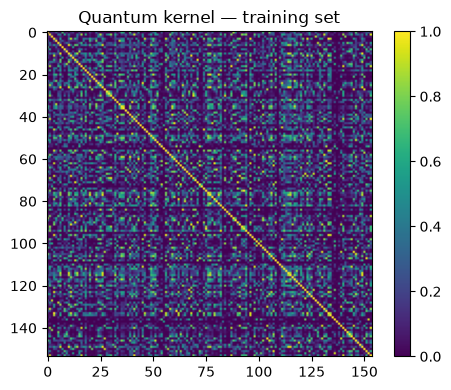

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
im = ax.imshow(K_train, cmap="viridis")
ax.set_title("Quantum kernel — training set")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [11]:
# X_all = np.vstack([X_train, X_test])
# y_all = np.concatenate([y_train, y_test])
# K_all = quantum_kernel_exact(feature_map, X_all, X_all)

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# for fold, (tr_idx, te_idx) in enumerate(skf.split(X_all, y_all)):
#     K_tr = K_all[np.ix_(tr_idx, tr_idx)]
#     K_te = K_all[np.ix_(te_idx, tr_idx)]
#     fold_model = SVC(kernel="precomputed", class_weight={0: 1, 1: 6})
#     fold_model.fit(K_tr, y_all[tr_idx])
#     fold_pred = fold_model.predict(K_te)
#     print(f"Fold {fold}:")
#     print(classification_report(y_all[te_idx], fold_pred))

starting first calc
starting job...
finished job.
starting second calc
starting job...
finished job.
finishing second
Fold 0:
              precision    recall  f1-score   support

         0.0       0.88      0.52      0.65        29
         1.0       0.36      0.80      0.50        10

    accuracy                           0.59        39
   macro avg       0.62      0.66      0.58        39
weighted avg       0.75      0.59      0.61        39

Fold 1:
              precision    recall  f1-score   support

         0.0       0.82      0.31      0.45        29
         1.0       0.29      0.80      0.42        10

    accuracy                           0.44        39
   macro avg       0.55      0.56      0.44        39
weighted avg       0.68      0.44      0.44        39

Fold 2:
              precision    recall  f1-score   support

         0.0       0.83      0.71      0.77        28
         1.0       0.47      0.64      0.54        11

    accuracy                           0

In [27]:

fold_metrics = {"accuracy": [], "precision": [], "recall": [], "f1": []}

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_all, y_all)):
    K_tr = K_all[np.ix_(tr_idx, tr_idx)]
    K_te = K_all[np.ix_(te_idx, tr_idx)]
    fold_model = SVC(kernel="precomputed", class_weight={0: 1, 1: 6})
    fold_model.fit(K_tr, y_all[tr_idx])
    fold_pred = fold_model.predict(K_te)

    fold_metrics["accuracy"].append(accuracy_score(y_all[te_idx], fold_pred))
    fold_metrics["precision"].append(precision_score(y_all[te_idx], fold_pred, zero_division=0))
    fold_metrics["recall"].append(recall_score(y_all[te_idx], fold_pred, zero_division=0))
    fold_metrics["f1"].append(f1_score(y_all[te_idx], fold_pred, zero_division=0))

print(f"{'metric':<10} {'mean':>6} {'std':>6}")
for name, values in fold_metrics.items():
    print(f"{name:<10} {np.mean(values):>6.2f} {np.std(values):>6.2f}")

metric       mean    std
accuracy     0.60   0.10
precision    0.39   0.07
recall       0.79   0.08
f1           0.52   0.06


In [16]:
qsvm = SVC(kernel="precomputed", class_weight={0: 1, 1: 2})
qsvm.fit(K_train, y_train)

y_pred = qsvm.predict(K_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.717948717948718
              precision    recall  f1-score   support

         0.0       0.88      0.72      0.79        29
         1.0       0.47      0.70      0.56        10

    accuracy                           0.72        39
   macro avg       0.67      0.71      0.68        39
weighted avg       0.77      0.72      0.73        39



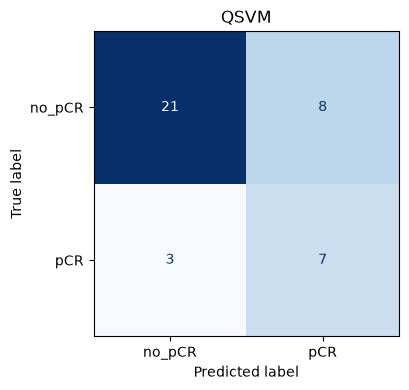

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
cm_qsvm = confusion_matrix(y_test, y_pred)
disp_qsvm = ConfusionMatrixDisplay(cm_qsvm, display_labels=["no_pCR", "pCR"])
disp_qsvm.plot(ax=axes, colorbar=False, cmap="Blues")
axes.set_title("QSVM")

plt.tight_layout()
plt.show()

In [28]:
#Adjast weights based on what?

weight_options = [1, 2, 3, 4, 6, 8, 10]
results = []

for w in weight_options:
    fold_recalls, fold_precisions, fold_f2s = [], [], []
    for tr_idx, te_idx in skf.split(X_all, y_all):
        K_tr = K_all[np.ix_(tr_idx, tr_idx)]
        K_te = K_all[np.ix_(te_idx, tr_idx)]
        model = SVC(kernel="precomputed", class_weight={0: 1, 1: w})
        model.fit(K_tr, y_all[tr_idx])
        pred = model.predict(K_te)
        fold_recalls.append(recall_score(y_all[te_idx], pred))
        fold_precisions.append(precision_score(y_all[te_idx], pred, zero_division=0))
        fold_f2s.append(fbeta_score(y_all[te_idx], pred, beta=2, zero_division=0))
    results.append((w, np.mean(fold_recalls), np.mean(fold_precisions), np.mean(fold_f2s)))

for w, r, p, f2 in results:
    print(f"weight=1:{w}  recall={r:.2f}  precision={p:.2f}  F2={f2:.2f}")

weight=1:1  recall=0.24  precision=0.69  F2=0.27
weight=1:2  recall=0.52  precision=0.51  F2=0.51
weight=1:3  recall=0.65  precision=0.44  F2=0.58
weight=1:4  recall=0.71  precision=0.38  F2=0.60
weight=1:6  recall=0.79  precision=0.39  F2=0.65
weight=1:8  recall=0.81  precision=0.36  F2=0.64
weight=1:10  recall=0.85  precision=0.35  F2=0.65


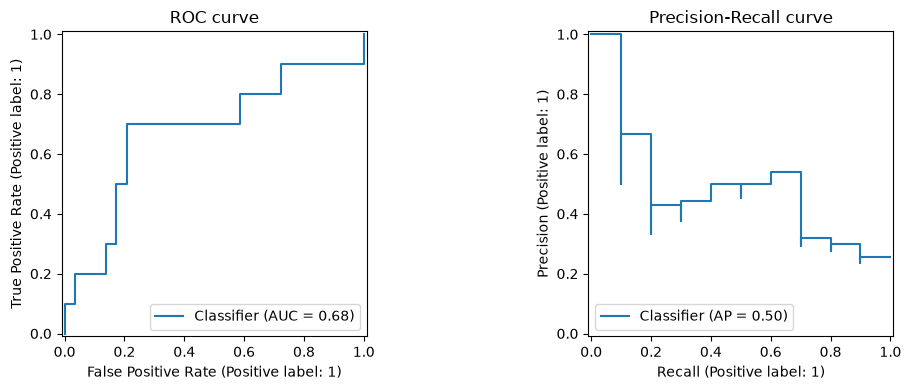

In [42]:
qsvm_proba = SVC(kernel="precomputed", class_weight={0: 1, 1: 2}, probability = True)

qsvm_proba.fit(K_train, y_train)
probs = qsvm_proba.predict_proba(K_test)[:, 1]  # probability of class 1 (pCR)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, probs, ax=axes[0])
axes[0].set_title("ROC curve")

PrecisionRecallDisplay.from_predictions(y_test, probs, ax=axes[1])
axes[1].set_title("Precision-Recall curve")

plt.tight_layout()
plt.show()

The ROC and precision-recall curves show the quantum kernel captures some signal  —
performance sits above the no-skill baselines (ROC-AUC > 0.5, and average precision
above the ~0.26 class-prevalence baseline). However, with only 39 test samples
(10 positive), both curves are built from too few points to be statistically stable. The dataset is too
small to draw firm conclusions about the model's real-world performance